# Simple Harmonic Oscillator using Euler Method

### Definition

A **Simple Harmonic Oscillator (SHO)** is a system that undergoes **Simple Harmonic Motion (SHM)**, in which the restoring force is directly proportional to the displacement from the equilibrium position and acts in the opposite direction.

The general restoring force is

$$
F_r=-kx
$$

where,

- $F_r$ = Restoring force
- $k$ = Spring constant (for a spring-mass system)
- $x$ = Displacement from equilibrium

> **Note:** The negative sign indicates that the restoring force always acts opposite to the displacement, pulling the object back toward the equilibrium position.



### Example

A **mass attached to an ideal spring** is the most common example of a Simple Harmonic Oscillator.

When the mass is displaced from its equilibrium position and released, it oscillates back and forth due to the restoring force provided by the spring.

---

### Prerequisite: Angular Frequency

The angular frequency is

$$
\omega=\sqrt{\frac{k}{m}}
$$

where,

- $\omega$ = Angular frequency (rad/s)
- $k$ = Spring constant (N/m)
- $m$ = Mass (kg)


## 1. Differential Equation of Motion

$$
\boxed{\frac{d^2x}{dt^2}+\omega^2x=0.}
$$

This is the **differential equation of the Simple Harmonic Oscillator**.

## 2. Equation of Acceleration

the acceleration is

$$
a=-\omega^2x.
$$

This shows that the acceleration is always directed toward the equilibrium position.



## 3. Equation of Velocity

The velocity at displacement $x$ is

$$
v=\omega\sqrt{A^2-x^2},
$$

where,

- $v$ = Velocity
- $A$ = Amplitude
- $x$ = Displacement
- $\omega$ = Angular frequency

The maximum velocity occurs at the equilibrium position ($x=0$):

$$
v_{\max}=\omega A.
$$

## 4. Energy of the Oscillator

The total mechanical energy remains constant.

## Potential Energy

$$
PE=\frac12kx^2
$$

## Kinetic Energy

$$
KE=\frac12mv^2
$$

Putting value of v

$$
KE=\frac12m\omega^2(A^2-x^2)
$$

## Total Energy

$$
E=KE+PE=\frac12kA^2
$$

Although kinetic and potential energy continuously interchange during the motion, the total mechanical energy remains constant for an ideal (undamped) oscillator.


## Governing Equation

The equation of motion of a spring-mass system is

$$
m\frac{d^2x}{dt^2} + kx = 0
$$

Introducing the velocity,

$$
v = \frac{dx}{dt}
$$

the second-order differential equation can be converted into the following system of first-order differential equations:

$$
\frac{dx}{dt} = v
$$

$$
\frac{dv}{dt} = -\frac{k}{m}x = -\omega^2x
$$

These coupled first-order equations describe the motion of the spring-mass system and are solved numerically using the **Euler Method**.

## Euler Method

The Euler Method is a first-order numerical technique used to approximate the solution of ordinary differential equations.

Given: at $x_0$     $y=y_0$  and   $y'=f(x,y)$

$$
y_{n+1} = y_n + h\,f(x_n,y_n)
$$

where, 
$h$= Step count

Now for SHM

At each time step, the displacement and velocity are updated using the current values.

The update equations are

$$
x_{n+1} = x_n + h\,v_n
$$

$$
v_{n+1} = v_n - h\frac{k}{m}x_n
$$

where

- $h$ is the time step.
- $x_n$ is the displacement at the $n^{\text{th}}$ time step.
- $v_n$ is the velocity at the $n^{\text{th}}$ time step.
- $k$ is the spring constant.
- $m$ is the mass of the object.

These equations are repeatedly applied to compute the motion of the spring-mass system over time.

##### Below is the code for SHM simulation using Euler method

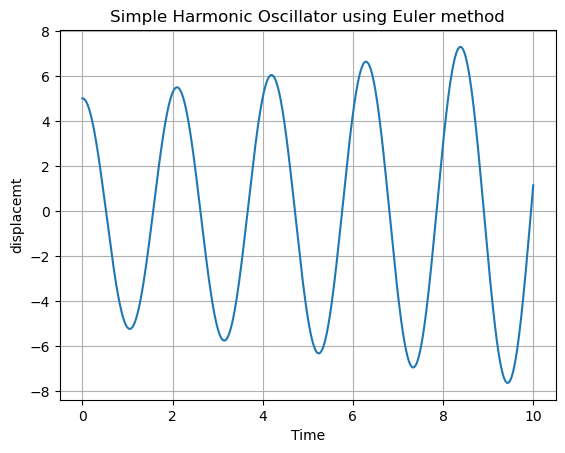

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Paramaters-
h=0.01        #step size
t0= 0         #initial time(s)
y0= 5.0       #initial condition(m)
tf= 10.0      #final time(s)
k= 9.0        #Spring constant(N/m)
m= 1.0        #mass(Kg)

# Create arrays
t= np.arange(t0, tf + h, h)
x = np.zeros(len(t))
v = np.zeros(len(t))

# Initial condition
x[0]= 5
v[0]=0

# Euler method
for i in range(len(t)-1):
    v[i+1] = v[i] - h*(k/m)*x[i]
    x[i+1] = x[i] + h*v[i]

plt.plot(t, x)
plt.xlabel("Time")
plt.ylabel("displacemt")
plt.title("Simple Harmonic Oscillator using Euler method")
plt.grid(True)

plt.savefig("Euler_simulation1.png",dpi=300)
plt.show()

## 6. Analytical solution: Position as a Function of Time

The analytical solution of the differential equation is

$$
x(t)=A\cos(\omega t+\phi),
$$

or equivalently,

$$
x(t)=A\sin(\omega t+\phi),
$$

where,

- $A$ = Amplitude
- $\omega$ = Angular frequency
- $\phi$ = Phase constant


#### Below is the code for Comparison simulation of both analytical and Euler method

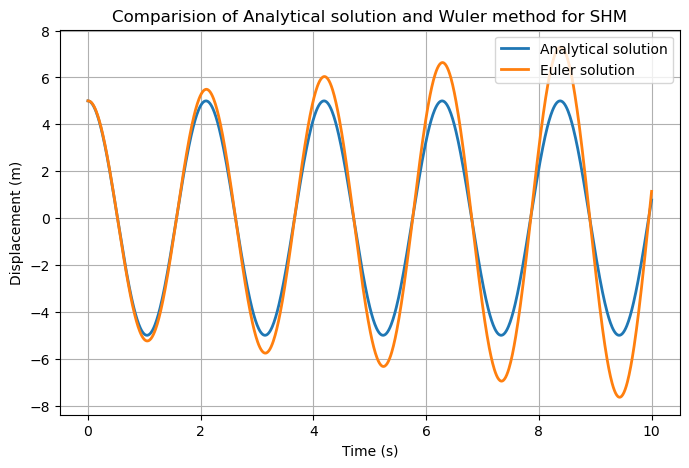

In [12]:
# Comparision with the Analytical solution

omega= (k/m)**0.5

y = y0 * np.cos(omega * t)

# Plot
plt.figure(figsize=(8,5))
plt.plot(t, y,linewidth=2,label="Analytical solution")
plt.plot(t, x, linewidth=2, label="Euler solution")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Comparision of Analytical solution and Wuler method for SHM")
plt.grid(True)
plt.legend(loc="upper right")

plt.savefig("Euler_simulation2.png",dpi=300)
plt.show()


#### Below is the code for Velocity time plot

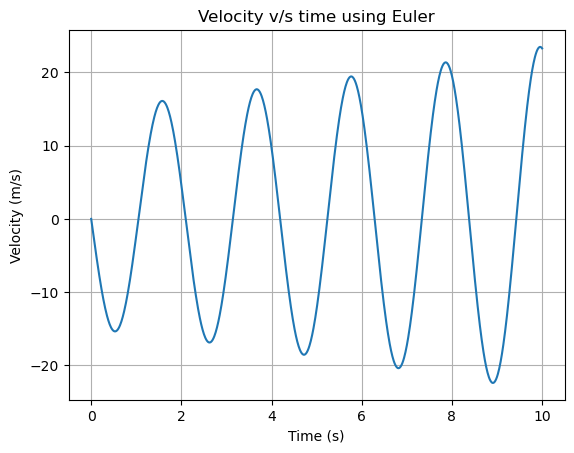

In [8]:
#Velocity vs time plot
plt.plot(t, v, label="Velocity")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Velocity v/s time using Euler")
plt.grid(True)

plt.savefig("Euler_simulation3.png",dpi=300)
plt.show()


#### Below is the code of energy time plot

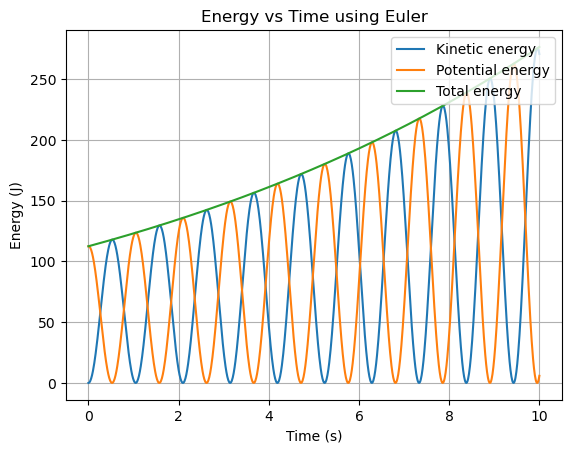

In [15]:
#Energy vs time plot

PE = 0.5*k*x**2           #Kinetic energy(J)
KE = 0.5*m*v**2           #Potential energy(J)
TE = PE + KE              #Total energy(J)

plt.plot(t, KE, label="Kinetic energy")
plt.plot(t, PE, label="Potential energy")
plt.plot(t, TE, label="Total energy")
plt.xlabel("Time (s)")
plt.ylabel("Energy (J)")
plt.title("Energy vs Time using Euler")
plt.grid(True)
plt.legend(loc="upper right")

plt.savefig("Euler_simulation4.png",dpi=300)
plt.show()


**For Energy vs time:**

In the analytical solution, total energy remains constant.

With the Euler Method, numerical errors accumulate and the total energy gradually drifts.

This illustrates one limitation of the standard Euler Method.

# Conclusion

The Euler Method successfully reproduces the oscillatory motion of a simple harmonic oscillator for sufficiently small time steps.

However, because the Euler Method is a first-order numerical method, the solution gradually deviates from the exact analytical solution, especially over long simulation times. More accurate methods such as RK2 and RK4 significantly reduce this numer